In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"complaints.csv")
df.head()

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_23336\534312631.py:6: DtypeWarning: Columns (16) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv(r"complaints.csv")


,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in t...,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689
3,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,Experian Information Solutions Inc.,AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195690
4,2025-06-20,Credit reporting or other personal consumer re...,Credit reporting,Incorrect information on your report,Account status incorrect,NaN,NaN,Experian Information Solutions Inc.,IL,60628,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195692


Product
Credit reporting or other personal consumer reports                             4834855
Credit reporting, credit repair services, or other personal consumer reports    2163857
Debt collection                                                                  799197
Mortgage                                                                         422254
Checking or savings account                                                      291178
Credit card                                                                      226686
Credit card or prepaid card                                                      206369
Money transfer, virtual currency, or money service                               145066
Credit reporting                                                                 140429
Student loan                                                                     109717
Bank account or service                                                           86205
Vehicle loan or lease   

C:\Users\Rahwa.B\AppData\Local\Temp\ipykernel_23336\1210466634.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=product_counts.values, y=product_counts.index, palette='viridis')


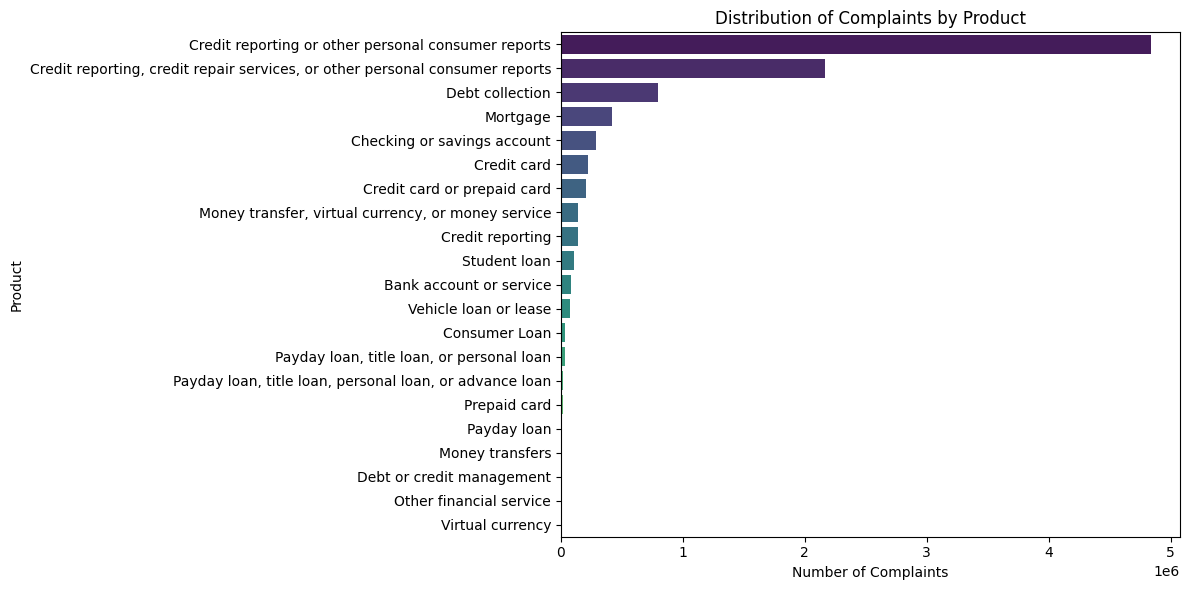

In [2]:
# Group and count complaints by Product
product_counts = df['Product'].value_counts().sort_values(ascending=False)

# Display the distribution
print(product_counts)

# Plot the distribution
plt.figure(figsize=(12, 6))
sns.barplot(x=product_counts.values, y=product_counts.index, palette='viridis')
plt.title('Distribution of Complaints by Product')
plt.xlabel('Number of Complaints')
plt.ylabel('Product')
plt.tight_layout()
plt.show()

count    2.980756e+06
mean     1.755976e+02
std      2.259282e+02
min      1.000000e+00
25%      5.900000e+01
50%      1.140000e+02
75%      2.090000e+02
max      6.469000e+03
Name: narrative_word_count, dtype: float64


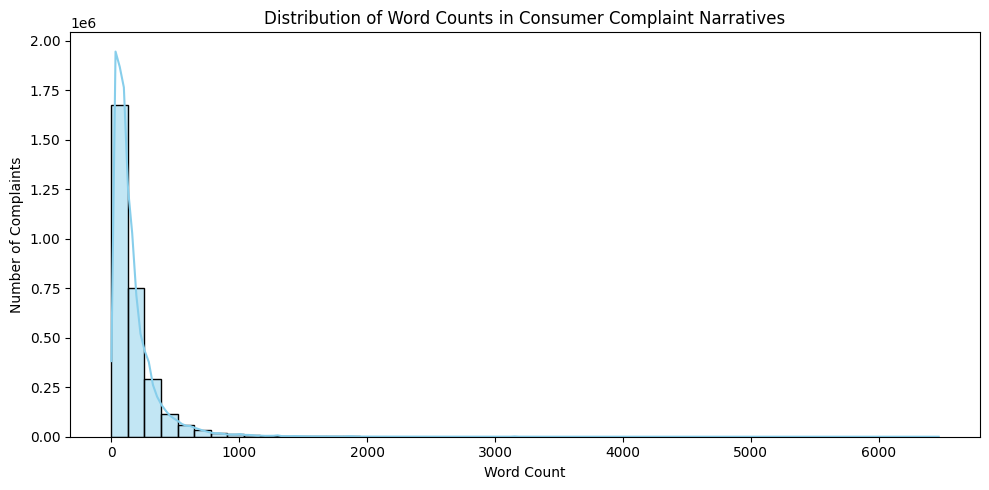

In [16]:
# Drop missing narratives
df = df.dropna(subset=['Consumer complaint narrative'])

# Calculate word count
df['narrative_word_count'] = df['Consumer complaint narrative'].apply(lambda x: len(str(x).split()))

# Basic stats
print(df['narrative_word_count'].describe())

# Visualize distribution
plt.figure(figsize=(10, 5))
sns.histplot(df['narrative_word_count'], bins=50, kde=True, color='skyblue')
plt.title('Distribution of Word Counts in Consumer Complaint Narratives')
plt.xlabel('Word Count')
plt.ylabel('Number of Complaints')
plt.tight_layout()
plt.show()

In [3]:
# Check for missing and non-missing narratives
with_narrative = df['Consumer complaint narrative'].notna().sum()
without_narrative = df['Consumer complaint narrative'].isna().sum()

# Print results
print(f"Complaints WITH narrative: {with_narrative}")
print(f"Complaints WITHOUT narrative: {without_narrative}")

Complaints WITH narrative: 2980756
Complaints WITHOUT narrative: 6629041


In [4]:
# Define the allowed product list
allowed_products = [
    'Credit card',
    'Personal loan',
    'Buy Now, Pay Later (BNPL)',
    'Savings account',
    'Money transfers'
]

# Filter the DataFrame
filtered_df = df[df['Product'].isin(allowed_products)]

# Display how many rows remain after filtering
print("Filtered dataset shape:", filtered_df.shape)


Filtered dataset shape: (232040, 18)


In [5]:
# First, drop rows with NaN in the narrative column
df = df.dropna(subset=['Consumer complaint narrative'])

# Then, remove rows where the narrative is empty or just whitespace
df = df[df['Consumer complaint narrative'].str.strip() != '']

# Check result
print(f"Remaining complaints with valid narratives: {df.shape[0]}")

Remaining complaints with valid narratives: 2980756


In [ ]:
import re

# Define boilerplate patterns to remove (customize this list as needed)
boilerplate_patterns = [
    r"i am writing to file a complaint",
    r"to whom it may concern",
    r"this is to inform you",
    r"i would like to report",
    r"please be advised that",
    r"i am writing regarding",
    r"i am writing to express",
    r"i want to raise a complaint",
    r"i am extremely disappointed",
    r"i am filing this complaint because",
    r"i have contacted your support team",
    r"this message is in reference to",
    r"i was advised to",
    r"i am reaching out to",
    r"i need to bring to your attention",
    r"i would like to formally complain",
    r"i hope this message finds you well",
    r"thank you for your time",
    r"i appreciate your attention to this matter",
    r"as a loyal customer",
    r"this issue has caused me significant inconvenience",
    r"i have tried multiple times to resolve this",
    r"i expect a prompt resolution",
    r"i am very frustrated",
    r"i’m disappointed with the service",
    r"this has been ongoing for",
    r"i was not informed that",
    r"i trusted your company",
    r"this has negatively impacted me",
    r"i would like to request",
]
  

# Compile into one regex pattern
boilerplate_regex = re.compile("|".join(boilerplate_patterns), re.IGNORECASE)

# Clean the narratives
def clean_text(text):
    text = str(text).lower()                                  # Lowercase
    text = boilerplate_regex.sub("", text)                    # Remove boilerplate
    text = re.sub(r'[^a-z0-9\s]', '', text)                   # Remove special characters
    text = re.sub(r'\s+', ' ', text).strip()                  # Normalize whitespace
    return text

df['cleaned_narrative'] = df['Consumer complaint narrative'].apply(clean_text)

# Preview
print(df[['Consumer complaint narrative', 'cleaned_narrative']].head())

df.to_csv("filtered_complaints.csv")


                            Consumer complaint narrative  \
76     XXXX XXXX XXXX XXXX XXXX XXXX XXXX XXXX Apt XX...   
359    Subject : Dispute of Unauthorized Hard Inquiri...   
11499  I signed a purchase agreement with Lennar Corp...   
11973  After checking my report, I found numerous acc...   
12237  A XXXX XXXX card was opened under my name by a...   
12532  I made the mistake of using my wellsfargo debi...   
13280  Dear CFPB, I have a secured credit card with c...   
13310  As I was reviewing a new dispute with XXXX XXX...   
13356  I sent the company a letter stating that their...   
13437  SUNRISE CREDIT SERVI, I am unaware of this deb...   
13506  I have a Citi rewards cards. The credit balanc...   
13520  Consumer Financial Protection Bureau ( CFPB ) ...   
13622  Was never notified of repossession. Once repos...   
13699  b'To Whom It May Concern,\n\nI am filing this ...   
13863  VALIDATION AND CEASE AND DESIST Account : To w...   
13955  b'I am writing to dispute the fol

In [7]:
# Drop the original column
df = df.drop(columns=['Consumer complaint narrative'])

# Save to CSV
df.to_csv("filtered_complaints.csv", index=False)
